<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/part2_experiment_2(LoRA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 2 — LoRA Rank Study on ResNet50

Investigates how the LoRA rank affects accuracy and trainable parameter count. We apply LoRA to the 9 convolutions of `layer4` (the most abstract block), keep the rest of the backbone frozen, and train the head normally. Four ranks are compared: 4, 8, 16, 32.

We use HuggingFace's `peft` library rather than implementing LoRA from scratch. A manual implementation was prototyped but `peft` handles the wrapping, frozen-weight bookkeeping, and parameter counting cleanly enough that the manual version added complexity without adding insight. The implementation logic is identical underneath: each wrapped conv gets two small matrices A and B, the original weight stays frozen, the forward pass computes `base(x) + scaling * B(A(x))` with B initialized to zero so training starts from the pretrained model exactly.

## 1. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import json, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
if device.type == 'cuda':
    print(f'gpu: {torch.cuda.get_device_name(0)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
gpu: NVIDIA L4


In [10]:
# install peft - not in colab by default
!pip install -q -U peft torchao
import peft
print(f'peft version: {peft.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.0 MB/s eta 0:00:00
peft version: 0.19.1


## 2. Paths and shared training config

Same config as Exp 1 for direct comparability. Ranks defined here so the experiment loop reads from one place.

In [16]:
DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL')
INDEX_DIR = DRIVE_ROOT / 'sample_index'
RESULTS_DIR = DRIVE_ROOT / 'results' / 'exp2_lora'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# same training config as exp1 - keeps comparison clean
IMG_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 0
NUM_EPOCHS = 20
LR = 1e-3                # higher than B's 1e-4 because LoRA params are random init like a head
WEIGHT_DECAY = 1e-4
PATIENCE = 5

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# the 4 ranks we sweep
RANKS = [1, 2, 4, 8, 16, 32]

print(f'results dir: {RESULTS_DIR}')
print(f'ranks to test: {RANKS}')

results dir: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/exp2_lora
ranks to test: [1, 2, 4, 8, 16, 32]


## 3. Copy dataset to local SSD + load sample index

Same pipeline as last exercise

In [4]:
import shutil
# 8min L4
# 4min A100


LOCAL_ROOT = Path('/content/dataset_local')
DRIVE_RAW = DRIVE_ROOT / 'raw'
EXPECTED = {'train': 4654, 'val': 1125, 'test': 1124}

def copy_split(split):
    src = DRIVE_RAW / split / 'images'
    dst = LOCAL_ROOT / split / 'images'
    dst.mkdir(parents=True, exist_ok=True)
    if len(list(dst.glob('*.png'))) == EXPECTED[split]:
        print(f'  {split}: already complete')
        return
    print(f'  {split}: copying {EXPECTED[split]} images...')
    t0 = time.time()
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print(f'  {split}: copied in {time.time()-t0:.0f}s')

print('copying dataset to local SSD...')
for split in ['train', 'val', 'test']:
    copy_split(split)
print('done.')

copying dataset to local SSD...
  train: already complete
  val: already complete
  test: already complete
done.


In [5]:
with open(INDEX_DIR / 'samples_train.json') as f: samples_train = json.load(f)
with open(INDEX_DIR / 'samples_val.json') as f:   samples_val = json.load(f)
with open(INDEX_DIR / 'samples_test.json') as f:  samples_test = json.load(f)
with open(INDEX_DIR / 'class_vocab.json') as f:   vocab = json.load(f)

CLASS_TO_IDX = vocab['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in vocab['idx_to_class'].items()}
NUM_CLASSES = len(CLASS_TO_IDX)
CLASSES = vocab['keep_classes']

# rewrite drive paths to local ssd
for split_samples in [samples_train, samples_val, samples_test]:
    for s in split_samples:
        s['img_path'] = s['img_path'].replace(str(DRIVE_RAW), str(LOCAL_ROOT))

print(f'classes: {NUM_CLASSES}')
print(f'train: {len(samples_train):,}  val: {len(samples_val):,}  test: {len(samples_test):,}')

classes: 11
train: 11,000  val: 2,750  test: 2,750


## 4. Pre-load to RAM

If `preloaded_*.pt` exists in `/content/dataset_local/` from earlier sessions, this loads should be around 10s. If not it creates a new session in around 3 min. In case is ran from the beggining


In [6]:
def preload_to_ram(samples):
    n = len(samples)
    imgs = torch.empty((n, 3, IMG_SIZE, IMG_SIZE), dtype=torch.uint8)
    labels = torch.empty((n,), dtype=torch.long)
    t0 = time.time()
    for i, s in enumerate(samples):
        img = Image.open(s['img_path']).convert('RGB')
        x1, y1, x2, y2 = s['bbox']
        crop = img.crop((x1, y1, x2, y2)).resize((IMG_SIZE, IMG_SIZE))
        imgs[i] = torch.from_numpy(np.asarray(crop)).permute(2, 0, 1)
        labels[i] = s['label']
        if (i+1) % 2000 == 0:
            print(f'  {i+1:,}/{n:,}')
    print(f'done: {n:,} in {time.time()-t0:.0f}s')
    return imgs, labels

class InMemoryDataset(Dataset):
    def __init__(self, imgs, labels):
        self.imgs = imgs; self.labels = labels
        self.mean = torch.tensor(IMAGENET_MEAN).view(3,1,1) * 255
        self.std = torch.tensor(IMAGENET_STD).view(3,1,1) * 255
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        x = self.imgs[i].float()
        return (x - self.mean) / self.std, self.labels[i]

CACHE_DIR = Path('/content/dataset_local')
def preload_or_load(samples, name):
    path = CACHE_DIR / f'preloaded_{name}.pt'
    if path.exists():
        print(f'{name}: loading cache...')
        cache = torch.load(path)
        return cache['imgs'], cache['labels']
    print(f'{name}: preloading...')
    imgs, labels = preload_to_ram(samples)
    torch.save({'imgs': imgs, 'labels': labels}, path)
    return imgs, labels

train_imgs, train_labels = preload_or_load(samples_train, 'train')
val_imgs, val_labels = preload_or_load(samples_val, 'val')
test_imgs, test_labels = preload_or_load(samples_test, 'test')

train_loader = DataLoader(InMemoryDataset(train_imgs, train_labels), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(InMemoryDataset(val_imgs, val_labels),     batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(InMemoryDataset(test_imgs, test_labels),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'loaders ready')

train: loading cache...
val: loading cache...
test: loading cache...
loaders ready


## 5. Shared helpers

Same train/eval loops as Exp 1. The `build_lora_model` function is the new piece — wraps a fresh ResNet50 with LoRA on layer4's 9 convolutions.

In [7]:
import torchvision.models as models
from torch.amp import autocast, GradScaler
from peft import LoraConfig, get_peft_model

def build_base_model(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

# the 9 convs in layer4 we want to wrap with LoRA
LORA_TARGETS = [
    "layer4.0.conv1", "layer4.0.conv2", "layer4.0.conv3",
    "layer4.1.conv1", "layer4.1.conv2", "layer4.1.conv3",
    "layer4.2.conv1", "layer4.2.conv2", "layer4.2.conv3",
]

def build_lora_model(num_classes, r):
    base = build_base_model(num_classes)
    config = LoraConfig(
        r=r,
        lora_alpha=r,                 # alpha=r is the standard convention
        target_modules=LORA_TARGETS,
        modules_to_save=["fc"],       # head trains normally, not as a LoRA pair
    )
    model = get_peft_model(base, config)
    return model

def count_trainable(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_n += xb.size(0)
    return total_loss / total_n, total_correct / total_n

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    per_class_correct = torch.zeros(NUM_CLASSES)
    per_class_total = torch.zeros(NUM_CLASSES)
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(xb)
            loss = criterion(logits, yb)
        preds = logits.argmax(1)
        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)
        for c in range(NUM_CLASSES):
            mask = (yb == c)
            per_class_total[c] += mask.sum().item()
            per_class_correct[c] += (preds[mask] == c).sum().item()
    per_class_acc = (per_class_correct / per_class_total.clamp(min=1)).tolist()
    return total_loss / total_n, total_correct / total_n, per_class_acc

print('helpers defined')

helpers defined


## 6. Smoke test, what `peft` does to the model

Build one LoRA model (r=8) and print its trainable parameter breakdown. This confirms only the LoRA matrices and the head get gradients, and gives us a sense of how the parameter count scales with r.

In [8]:
sanity_model = build_lora_model(NUM_CLASSES, r=8).to(device)
sanity_model.print_trainable_parameters()

# manual count for cross-check
trainable, total = count_trainable(sanity_model)
print(f'\nmanual count: {trainable:,} / {total:,} trainable ({100*trainable/total:.3f}%)')

# quick look at how many params each rank gives us
print(f'\ntrainable params by rank (estimate):')
for r in RANKS:
    m = build_lora_model(NUM_CLASSES, r=r)
    t, _ = count_trainable(m)
    print(f'  r={r:2d}: {t:,}')
    del m

trainable params: 260,107 || all params: 23,790,678 || trainable%: 1.0933

manual count: 260,107 / 23,790,678 trainable (1.093%)

trainable params by rank (estimate):
  r= 4: 141,323
  r= 8: 260,107
  r=16: 497,675
  r=32: 972,811


## 7. Training loop over all 4 ranks

Trains each rank in sequence. Same training loop as Exp 1 with early stopping, best checkpoint, history dump. Each rank gets its own subfolder under `results/exp2_lora/lora_rN/`.

In [9]:
# expected 3-4 min per rank, 12-15 min total ON A100
# x2 on L4
def train_one_rank(r):
    print(f'\n{"="*60}\nrank r={r}\n{"="*60}')
    rank_dir = RESULTS_DIR / f'lora_r{r}'
    rank_dir.mkdir(parents=True, exist_ok=True)

    model = build_lora_model(NUM_CLASSES, r=r).to(device)
    trainable, total = count_trainable(model)
    print(f'trainable: {trainable:,} / {total:,}')

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR, weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'lr': [], 'per_class_val_acc': [], 'rank': r, 'trainable_params': trainable}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    t0 = time.time()
    ckpt_path = rank_dir / 'best.pt'

    for epoch in range(NUM_EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc, per_class_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        history['per_class_val_acc'].append(per_class_acc)

        elapsed = (time.time() - t0) / 60
        print(f'  epoch {epoch:2d} | train {tr_loss:.4f}/{tr_acc:.4f} | '
              f'val {val_loss:.4f}/{val_acc:.4f} | lr {current_lr:.2e} | {elapsed:.1f} min')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({'model_state': model.state_dict(),
                        'epoch': epoch, 'val_loss': val_loss, 'val_acc': val_acc, 'rank': r},
                       ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f'  early stopping at epoch {epoch}')
                break

    history['total_time_min'] = (time.time() - t0) / 60

    # final test eval on best checkpoint
    ckpt = torch.load(ckpt_path)
    model.load_state_dict(ckpt['model_state'])
    test_loss, test_acc, test_per_class = evaluate(model, test_loader, criterion)
    history['test_loss'] = test_loss
    history['test_acc'] = test_acc
    history['test_per_class_acc'] = test_per_class

    with open(rank_dir / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)

    print(f'  test acc: {test_acc:.4f} | time: {history["total_time_min"]:.1f} min')
    del model
    torch.cuda.empty_cache()
    return history

all_histories = {}
for r in RANKS:
    all_histories[r] = train_one_rank(r)

print('\nall ranks done')


rank r=4
trainable: 141,323 / 23,671,894
  epoch  0 | train 0.8497/0.7805 | val 0.2722/0.9138 | lr 1.00e-03 | 0.4 min
  epoch  1 | train 0.1816/0.9429 | val 0.1530/0.9549 | lr 1.00e-03 | 0.7 min
  epoch  2 | train 0.0837/0.9773 | val 0.1251/0.9644 | lr 1.00e-03 | 1.0 min
  epoch  3 | train 0.0512/0.9854 | val 0.1184/0.9615 | lr 1.00e-03 | 1.4 min
  epoch  4 | train 0.0306/0.9925 | val 0.0906/0.9724 | lr 1.00e-03 | 1.7 min
  epoch  5 | train 0.0178/0.9965 | val 0.0941/0.9738 | lr 1.00e-03 | 2.0 min
  epoch  6 | train 0.0153/0.9965 | val 0.0786/0.9800 | lr 1.00e-03 | 2.4 min
  epoch  7 | train 0.0170/0.9952 | val 0.0884/0.9771 | lr 1.00e-03 | 2.7 min
  epoch  8 | train 0.0080/0.9987 | val 0.0749/0.9804 | lr 1.00e-03 | 3.0 min
  epoch  9 | train 0.0065/0.9984 | val 0.0817/0.9782 | lr 1.00e-03 | 3.4 min
  epoch 10 | train 0.0069/0.9981 | val 0.0908/0.9753 | lr 1.00e-03 | 3.7 min
  epoch 11 | train 0.0045/0.9990 | val 0.0887/0.9807 | lr 5.00e-04 | 4.1 min
  epoch 12 | train 0.0029/0.9997 |

## 7.1 Extension, Ultra-low ranks (r=1, r=2)

Was curious to an lower extension. The LoRA paper reports that r=1 can be competitive on some tasks (Claude). Tests whether our dataset's saturation hides this effect or if r=1/r=2 fall meaningfully behind r=4.



In [13]:
# 12 min total L4
EXTRA_RANKS = [1, 2]

for r in EXTRA_RANKS:
    all_histories[r] = train_one_rank(r)

print('\nextra ranks done')


rank r=1
trainable: 52,235 / 23,582,806
  epoch  0 | train 0.9953/0.7496 | val 0.3940/0.8840 | lr 1.00e-03 | 0.3 min
  epoch  1 | train 0.2889/0.9140 | val 0.2257/0.9331 | lr 1.00e-03 | 0.6 min
  epoch  2 | train 0.1693/0.9506 | val 0.1700/0.9509 | lr 1.00e-03 | 0.9 min
  epoch  3 | train 0.1152/0.9687 | val 0.1478/0.9589 | lr 1.00e-03 | 1.2 min
  epoch  4 | train 0.0873/0.9763 | val 0.1205/0.9669 | lr 1.00e-03 | 1.5 min
  epoch  5 | train 0.0641/0.9855 | val 0.1043/0.9713 | lr 1.00e-03 | 1.8 min
  epoch  6 | train 0.0462/0.9910 | val 0.1074/0.9687 | lr 1.00e-03 | 2.1 min
  epoch  7 | train 0.0401/0.9916 | val 0.1113/0.9695 | lr 1.00e-03 | 2.4 min
  epoch  8 | train 0.0295/0.9948 | val 0.0956/0.9735 | lr 1.00e-03 | 2.8 min
  epoch  9 | train 0.0230/0.9965 | val 0.0951/0.9705 | lr 1.00e-03 | 3.1 min
  epoch 10 | train 0.0203/0.9974 | val 0.1088/0.9705 | lr 1.00e-03 | 3.4 min
  epoch 11 | train 0.0175/0.9977 | val 0.1013/0.9727 | lr 1.00e-03 | 3.7 min
  epoch 12 | train 0.0157/0.9975 | 

## 8. Comparison across ranks

Plots val loss and val acc for all 4 ranks overlaid. Summary table compares test acc, trainable params, and time. The interesting question is whether more rank actually helps or saturates quickly.

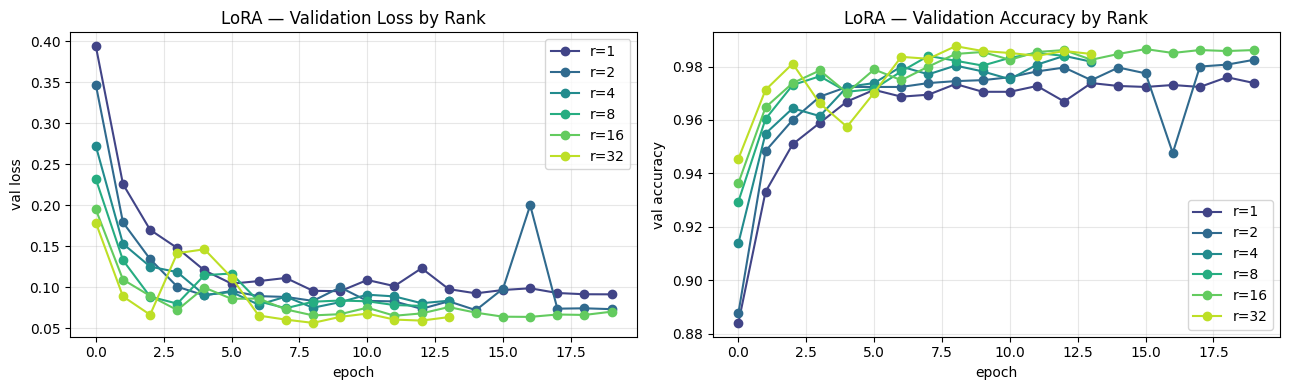


 rank   test acc  test loss    trainable  time (min)
-------------------------------------------------------
    1     0.9702     0.1128       52,235         6.1
    2     0.9742     0.0916       81,931         6.1
    4     0.9724     0.0982      141,323         4.7
    8     0.9767     0.0881      260,107         4.4
   16     0.9818     0.0786      497,675         6.2
   32     0.9847     0.0633      972,811         4.3

per-class test accuracy by rank:
class            r= 1  r= 2  r= 4  r= 8  r=16  r=32
---------------------------------------------------
box              0.976  0.988  0.980  0.984  0.984  0.988
ceiling          0.964  0.984  0.988  0.988  0.984  0.996
floor            0.980  0.972  0.984  0.988  0.984  0.984
floor_decal      0.996  1.000  0.996  1.000  1.000  1.000
lamp             0.976  0.972  0.988  0.980  0.988  0.984
pallet           0.980  0.988  0.984  0.980  0.988  0.996
pillar           0.952  0.964  0.928  0.960  0.980  0.984
rack             0.972  0.97

In [17]:
# reload from disk so this cell can be rerun without re-training
hist = {}
for r in RANKS:
    with open(RESULTS_DIR / f'lora_r{r}' / 'history.json') as f:
        hist[r] = json.load(f)

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(RANKS)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for r, color in zip(RANKS, colors):
    epochs_run = range(len(hist[r]['val_loss']))
    axes[0].plot(epochs_run, hist[r]['val_loss'], label=f'r={r}', color=color, marker='o')
    axes[1].plot(epochs_run, hist[r]['val_acc'],  label=f'r={r}', color=color, marker='o')

axes[0].set_xlabel('epoch'); axes[0].set_ylabel('val loss')
axes[0].set_title('LoRA — Validation Loss by Rank'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val accuracy')
axes[1].set_title('LoRA — Validation Accuracy by Rank'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_curves.png', dpi=120)
plt.show()

# summary table
print(f'\n{"rank":>5}  {"test acc":>9}  {"test loss":>9}  {"trainable":>11}  {"time (min)":>10}')
print('-' * 55)
for r in RANKS:
    h = hist[r]
    print(f'{r:>5}  {h["test_acc"]:>9.4f}  {h["test_loss"]:>9.4f}  '
          f'{h["trainable_params"]:>11,d}  {h["total_time_min"]:>10.1f}')

# per-class test acc
print(f'\nper-class test accuracy by rank:')
header = f'{"class":15s}  ' + '  '.join(f'r={r:>2}' for r in RANKS)
print(header); print('-' * len(header))
for cls, idx in sorted(CLASS_TO_IDX.items(), key=lambda x: x[1]):
    row = f'{cls:15s}  ' + '  '.join(f'{hist[r]["test_per_class_acc"][idx]:.3f}' for r in RANKS)
    print(row)

## 9. Comparison against Experiment 1 (A, B, C)

Pulls in the test accuracies from Exp 1 to put LoRA results in context. The interesting comparison is best-LoRA vs B (full fine-tune): how can a method with <1% of the trainable params match a method with 100%? And "fight"

In [18]:
exp1_dir = DRIVE_ROOT / 'results' / 'exp1_gradual_unfreezing'
exp1 = {}
for v in ['A', 'B', 'C']:
    with open(exp1_dir / f'exp1_{v}' / 'history.json') as f:
        exp1[v] = json.load(f)

print(f'{"method":30s}  {"test acc":>9}  {"trainable":>13}  {"% of full":>10}')
print('-' * 70)
total_params = 23_530_571
for v, name in [('A', 'Linear Probing'), ('B', 'Full Fine-Tuning'), ('C', 'Progressive Unfreezing')]:
    h = exp1[v]
    # exp1 doesn't store trainable count - infer from method
    trainable = {'A': 22_539, 'B': total_params, 'C': 14_987_275}[v]  # approx for C at best epoch
    pct = 100 * trainable / total_params
    print(f'{name:30s}  {h["test_acc"]:>9.4f}  {trainable:>13,d}  {pct:>9.2f}%')

for r in RANKS:
    h = hist[r]
    pct = 100 * h["trainable_params"] / total_params
    print(f'{f"LoRA r={r}":30s}  {h["test_acc"]:>9.4f}  {h["trainable_params"]:>13,d}  {pct:>9.2f}%')

method                           test acc      trainable   % of full
----------------------------------------------------------------------
Linear Probing                     0.9527         22,539       0.10%
Full Fine-Tuning                   0.9884     23,530,571     100.00%
Progressive Unfreezing             0.9905     14,987,275      63.69%
LoRA r=1                           0.9702         52,235       0.22%
LoRA r=2                           0.9742         81,931       0.35%
LoRA r=4                           0.9724        141,323       0.60%
LoRA r=8                           0.9767        260,107       1.11%
LoRA r=16                          0.9818        497,675       2.12%
LoRA r=32                          0.9847        972,811       4.13%
